In [1]:
import torch
from transformers import Qwen2VLForConditionalGeneration, Qwen2VLProcessor
from qwen_vl_utils import process_vision_info



/root/lingo-qa-fine-tune/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_id = "Qwen/Qwen2-VL-2B-Instruct"

device = torch.device("cuda")

In [3]:
# Load model and tokenizer
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, device_map="auto", torch_dtype=torch.bfloat16
)
processor = Qwen2VLProcessor.from_pretrained(model_id)

`torch_dtype` is deprecated! Use `dtype` instead!
Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 13981.01it/s]
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 9642.08it/s]


In [ ]:
import pandas as pd
df = pd.read_parquet("./data/val/val.parquet")

In [107]:
df

,question_id,segment_id,images,question,answer
0,1a938d25604410ccd63b60285919eaec,f2e4286e94457b8605069190e29f955a,[images/val/f2e4286e94457b8605069190e29f955a/0...,"Is there a traffic light? If yes, what color i...","Yes, green."
1,1a938d25604410ccd63b60285919eaec,f2e4286e94457b8605069190e29f955a,[images/val/f2e4286e94457b8605069190e29f955a/0...,"Is there a traffic light? If yes, what color i...","Yes, a temporary traffic light. It is showing ..."
2,49cd6149f02ec01ee03a6eb8287ab2df,f2e4286e94457b8605069190e29f955a,[images/val/f2e4286e94457b8605069190e29f955a/0...,How many pedestrians can be seen?,None.
3,49cd6149f02ec01ee03a6eb8287ab2df,f2e4286e94457b8605069190e29f955a,[images/val/f2e4286e94457b8605069190e29f955a/0...,How many pedestrians can be seen?,No pedestrian can be seen.
4,c6050fe51d3408b1eaef27e08e7f1956,f2e4286e94457b8605069190e29f955a,[images/val/f2e4286e94457b8605069190e29f955a/0...,What is the current action and its justificati...,"The car starts and moves right, because the ve..."
...,...,...,...,...,...
135,61804c43c7287cd9045a67b7b7501af5,fbdf56c8cf8500903a2b6b88f84522f0,[images/val/fbdf56c8cf8500903a2b6b88f84522f0/0...,Is there any vehicle in the lane to your left?...,No.
136,a6df923bb4967b7d689f7cd253a1dd03,fbdf56c8cf8500903a2b6b88f84522f0,[images/val/fbdf56c8cf8500903a2b6b88f84522f0/0...,Is it safe to accelerate considering the curre...,"Yes, there is an increasing amount of space be..."
137,a6df923bb4967b7d689f7cd253a1dd03,fbdf56c8cf8500903a2b6b88f84522f0,[images/val/fbdf56c8cf8500903a2b6b88f84522f0/0...,Is it safe to accelerate considering the curre...,"Yes, the vehicles ahead are accelerating and t..."
138,ee746fd004096aeccdef57c5ed6ca3be,fbdf56c8cf8500903a2b6b88f84522f0,[images/val/fbdf56c8cf8500903a2b6b88f84522f0/0...,What is the current action and its justificati...,"The car accelerates, in order to match the spe..."


In [108]:
system_message = "You are an autonomous driving agents, and you will be asked questions about driving scenes. Answer the questio directly without uncessary details."

images = [
    "data/val/images/val/f2e4286e94457b8605069190e29f955a/" + f"{i}.jpg"
    for i in range(5)
]


sample = {
        "images": images[4:],
        "messages": [
            {
                "role": "system",
                "content": [
                    {"type": "text", "text": system_message + ' How many pedestrians can be seen?'}
                ] + [
                     {"type": "image", "image": img}
                    for img in images[4:]
                ],
            },            
        ]
}

In [109]:
text_input = processor.apply_chat_template(
    sample["messages"],  # Use the sample without the system message
    tokenize=False,
    add_generation_prompt=True,
)

# Process the visual input from the sample
image_inputs, _ = process_vision_info(sample["messages"])

model_inputs = processor(
        text=[text_input],
        images=image_inputs,
        return_tensors="pt",
).to(device)

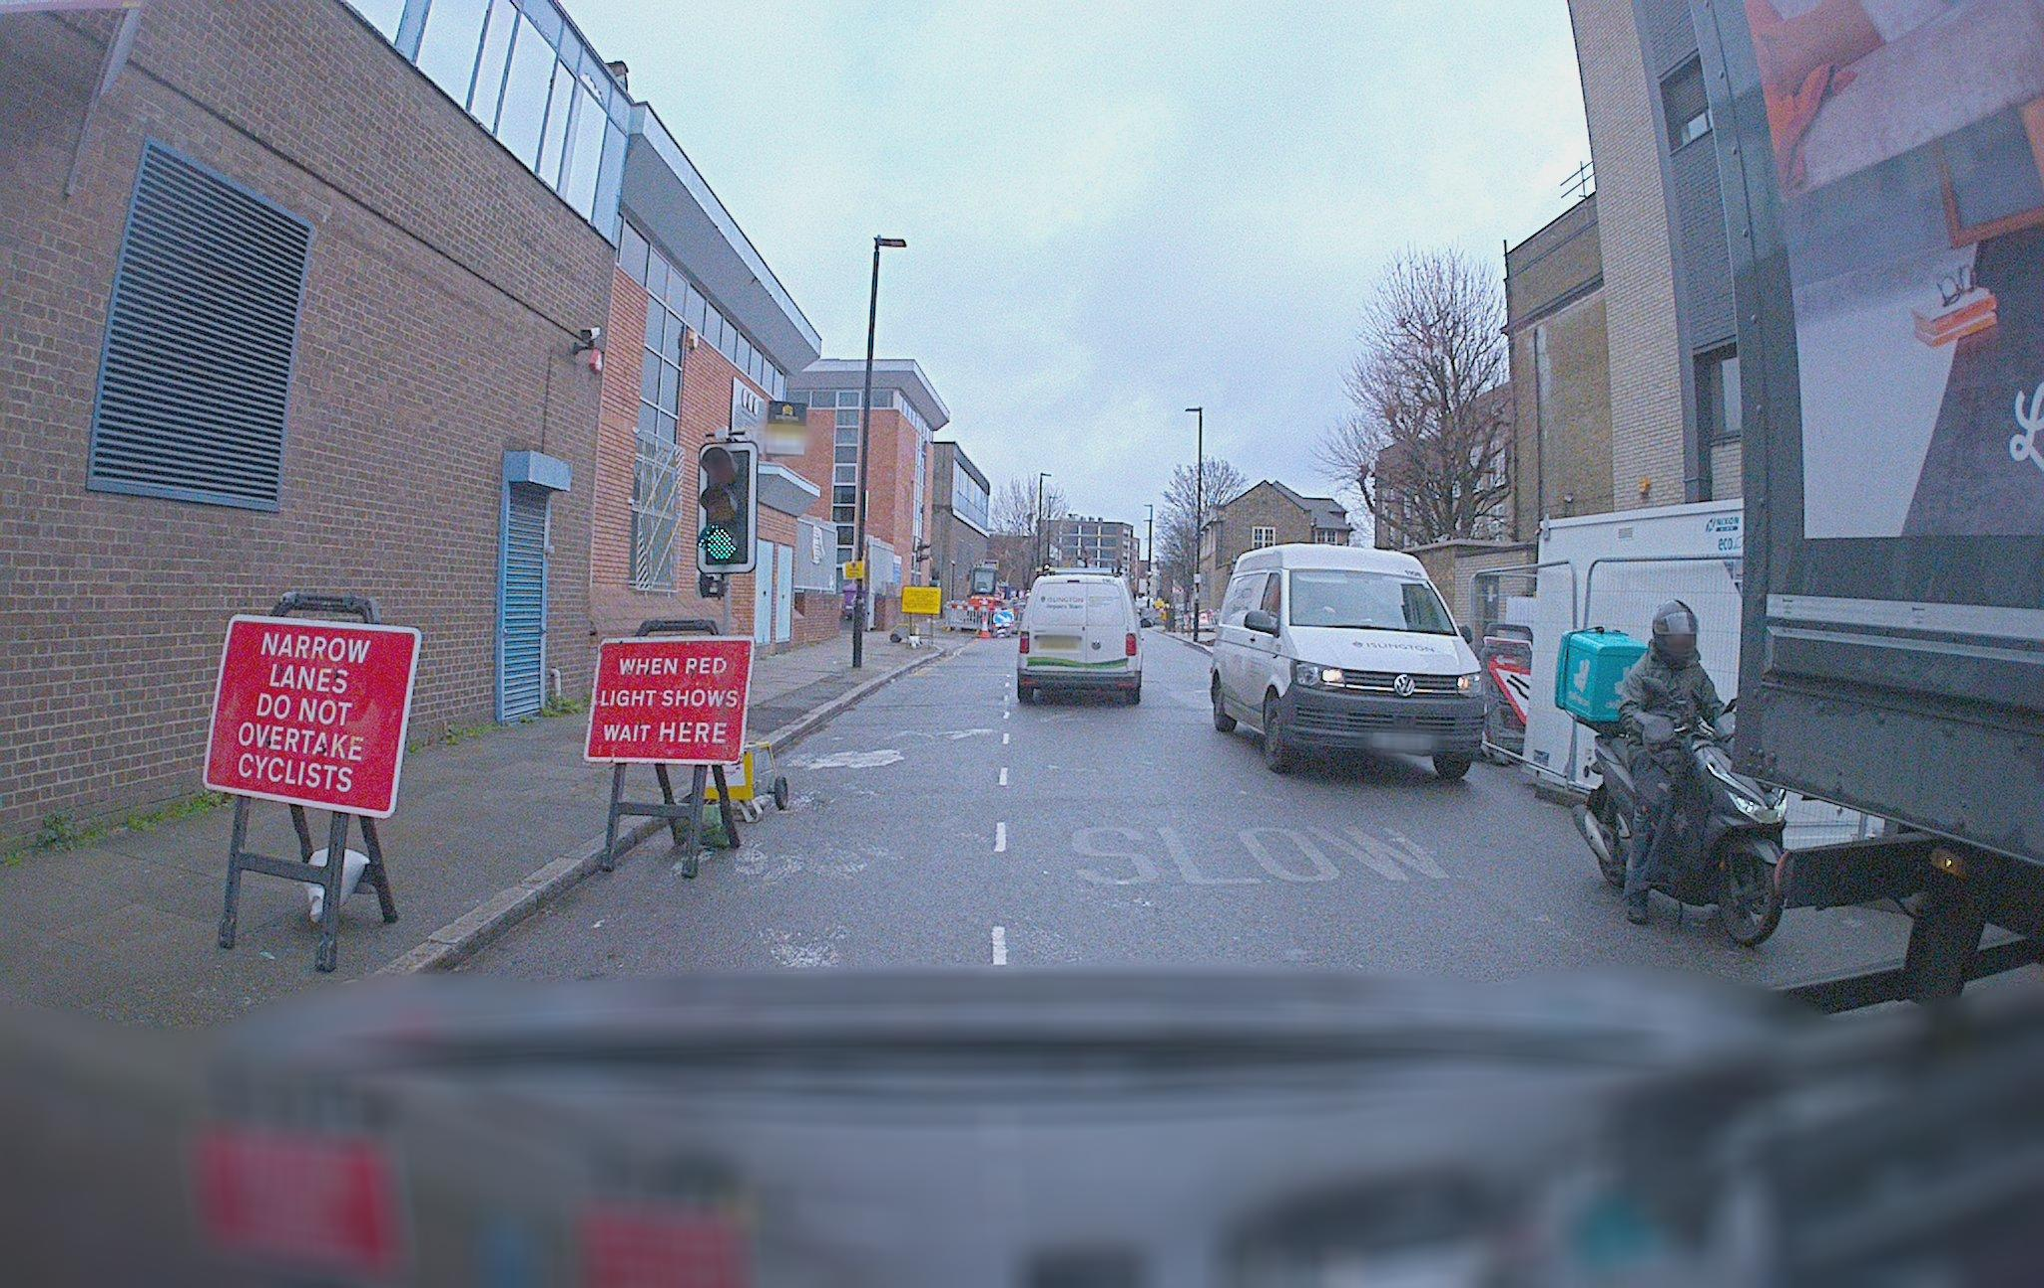

In [89]:
image_inputs[0]

In [45]:
model = peft_model.merge_and_unload().eval()

In [62]:
df.iloc[0][["images", "question", "answer"]].tolist()

[array(['images/val/f2e4286e94457b8605069190e29f955a/0.jpg',
        'images/val/f2e4286e94457b8605069190e29f955a/1.jpg',
        'images/val/f2e4286e94457b8605069190e29f955a/2.jpg',
        'images/val/f2e4286e94457b8605069190e29f955a/3.jpg',
        'images/val/f2e4286e94457b8605069190e29f955a/4.jpg'], dtype=object),
 'Is there a traffic light? If yes, what color is displayed?',
 'Yes, green.']

In [90]:
images[0]

'data/val/images/val/f2e4286e94457b8605069190e29f955a/0.jpg'

In [110]:
max_new_tokens = 100

# Generate text with the model
generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)

# Trim the generated ids to remove the input ids
trimmed_generated_ids = [out_ids[len(in_ids) :] for in_ids, out_ids in zip(model_inputs.input_ids, generated_ids)]

# Decode the output text
output_text = processor.batch_decode(
trimmed_generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
)


In [111]:
output_text

['There are no pedestrians visible in the image.']

In [ ]:
from dataset import LingoQADataset

train_dataset = LingoQADataset("./data/val/val.parquet", image_dir="./data/val/", processor=processor)
val_dataset = LingoQADataset("./data/val/val.parquet", image_dir="./data/val/", processor=processor)

In [5]:
from peft import LoraConfig, get_peft_model

# Configure LoRA
peft_config = LoraConfig(
    lora_alpha=16,
    lora_dropout=0.05,
    r=8,
    bias="none",
    target_modules=["q_proj", "v_proj"],
    task_type="CAUSAL_LM",
)

# Apply PEFT model adaptation
peft_model = get_peft_model(model, peft_config)

# Print trainable parameters
peft_model.print_trainable_parameters()

trainable params: 1,089,536 || all params: 2,210,075,136 || trainable%: 0.0493


In [10]:
from trl import SFTConfig

# Configure training arguments
training_args = SFTConfig(
    output_dir="qwen2-2b-finetune",  # Directory to save the model
    num_train_epochs=3,  # Number of training epochs
    per_device_train_batch_size=1,  # Batch size for training
    per_device_eval_batch_size=1,  # Batch size for evaluation
    gradient_accumulation_steps=8,  # Steps to accumulate gradients
    gradient_checkpointing_kwargs={"use_reentrant": False},  # Options for gradient checkpointing
    max_length=None,
    # Optimizer and scheduler settings
    optim="adamw_torch_fused",  # Optimizer type
    learning_rate=2e-4,  # Learning rate for training
    # Logging and evaluation
    logging_steps=10,  # Steps interval for logging
    # eval_steps=10,  # Steps interval for evaluation
    # eval_strategy="steps",  # Strategy for evaluation
    save_strategy="steps",  # Strategy for saving the model
    save_steps=20,  # Steps interval for saving
    # Mixed precision and gradient settings
    bf16=True,  # Use bfloat16 precision
    max_grad_norm=0.3,  # Maximum norm for gradient clipping
    warmup_ratio=0.03,  # Ratio of total steps for warmup
    # Hub and reporting
    report_to=None,  # Reporting tool for tracking metrics
)

In [7]:
from trl import SFTTrainer


In [11]:
trainer = SFTTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_dataset,
    # eval_dataset=val_dataset,
    peft_config=peft_config,
    processing_class=processor,
)

/root/lingo-qa-fine-tune/.venv/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [12]:
trainer.train()

Step,Training Loss
10,18.060200
20,16.130300
30,11.132700
40,9.193600
50,8.544800
60,8.194200
70,8.003200
80,7.909200
90,7.861100
100,7.824200


KeyboardInterrupt: 

In [14]:
import gc
import time


def clear_memory():
    # Delete variables if they exist in the current global scope
    if "inputs" in globals():
        del globals()["inputs"]
    if "model" in globals():
        del globals()["model"]
    if "processor" in globals():
        del globals()["processor"]
    if "trainer" in globals():
        del globals()["trainer"]
    if "peft_model" in globals():
        del globals()["peft_model"]
    if "bnb_config" in globals():
        del globals()["bnb_config"]
    time.sleep(2)

    # Garbage collection and clearing CUDA memory
    gc.collect()
    time.sleep(2)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    time.sleep(2)
    gc.collect()
    time.sleep(2)

    print(f"GPU allocated memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"GPU reserved memory: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")


clear_memory()

GPU allocated memory: 6.19 GB
GPU reserved memory: 6.25 GB
